In [1]:
# Cell 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Cell 2: Load the dataset
df = pd.read_csv('/content/CC GENERAL.csv')

# Basic shape check
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 8950, Columns: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
# STEP 2 — Basic info & statistics
# Cell 3: Data types and null check
df.info()

# Cell 4: Statistical summary
df.describe().round(2)
print("----------------------")

# Cell 5: Check missing values
missing = df.isnull().sum()
print(missing)
print("----------------------")

missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,
                            'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [3]:
# You will find: MINIMUM_PAYMENTS has ~313 nulls (3.5%) and CREDIT_LIMIT has ~1 null. We fix this in Phase 3.

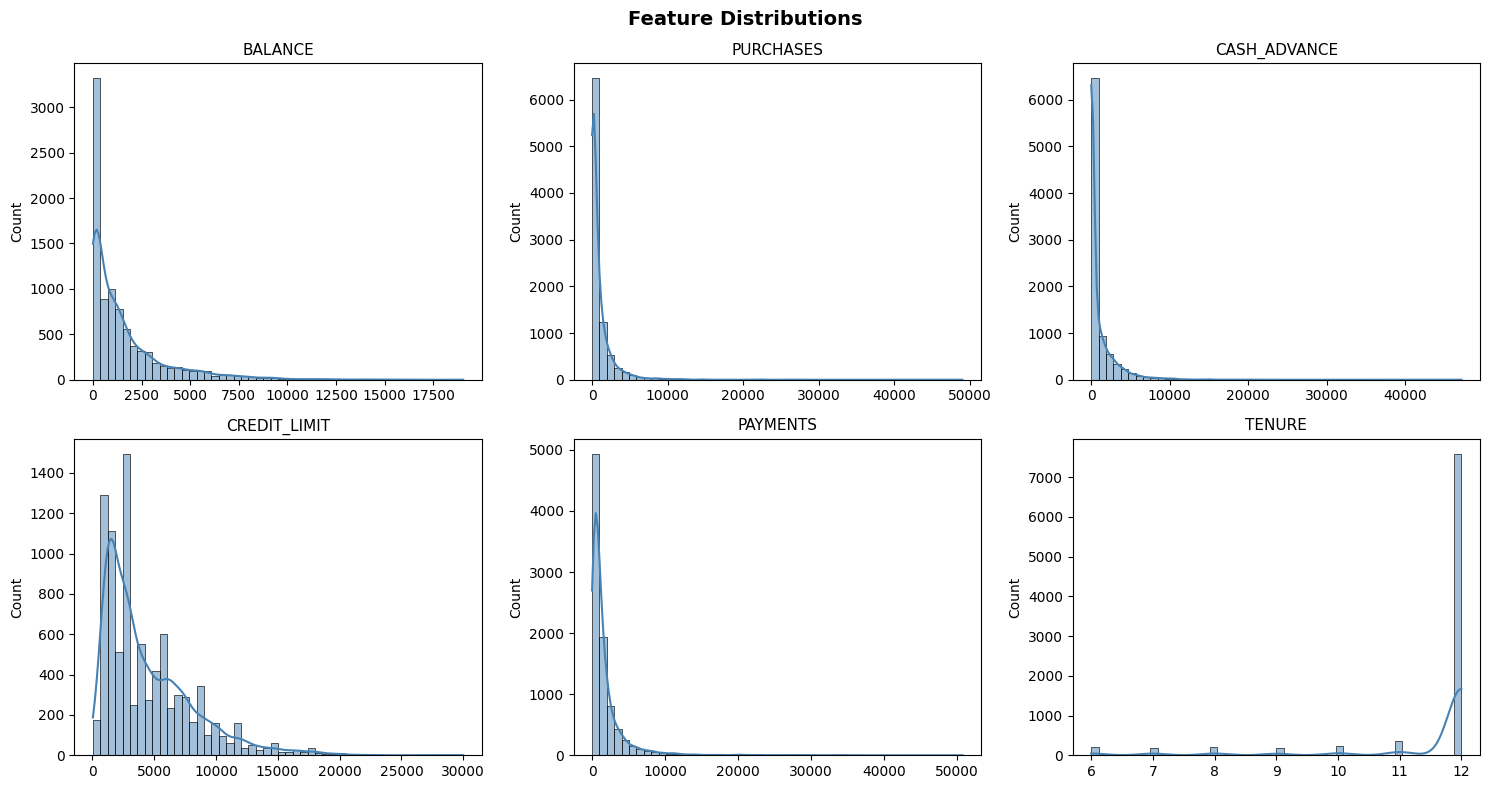

In [4]:
# STEP 3 — Visualize distributions

# Cell 6: Distribution plots for key columns
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
            'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    sns.histplot(df[col].dropna(), bins=50,
                 ax=axes[i], color='steelblue', kde=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../outputs/distributions.png', dpi=150)
plt.show()

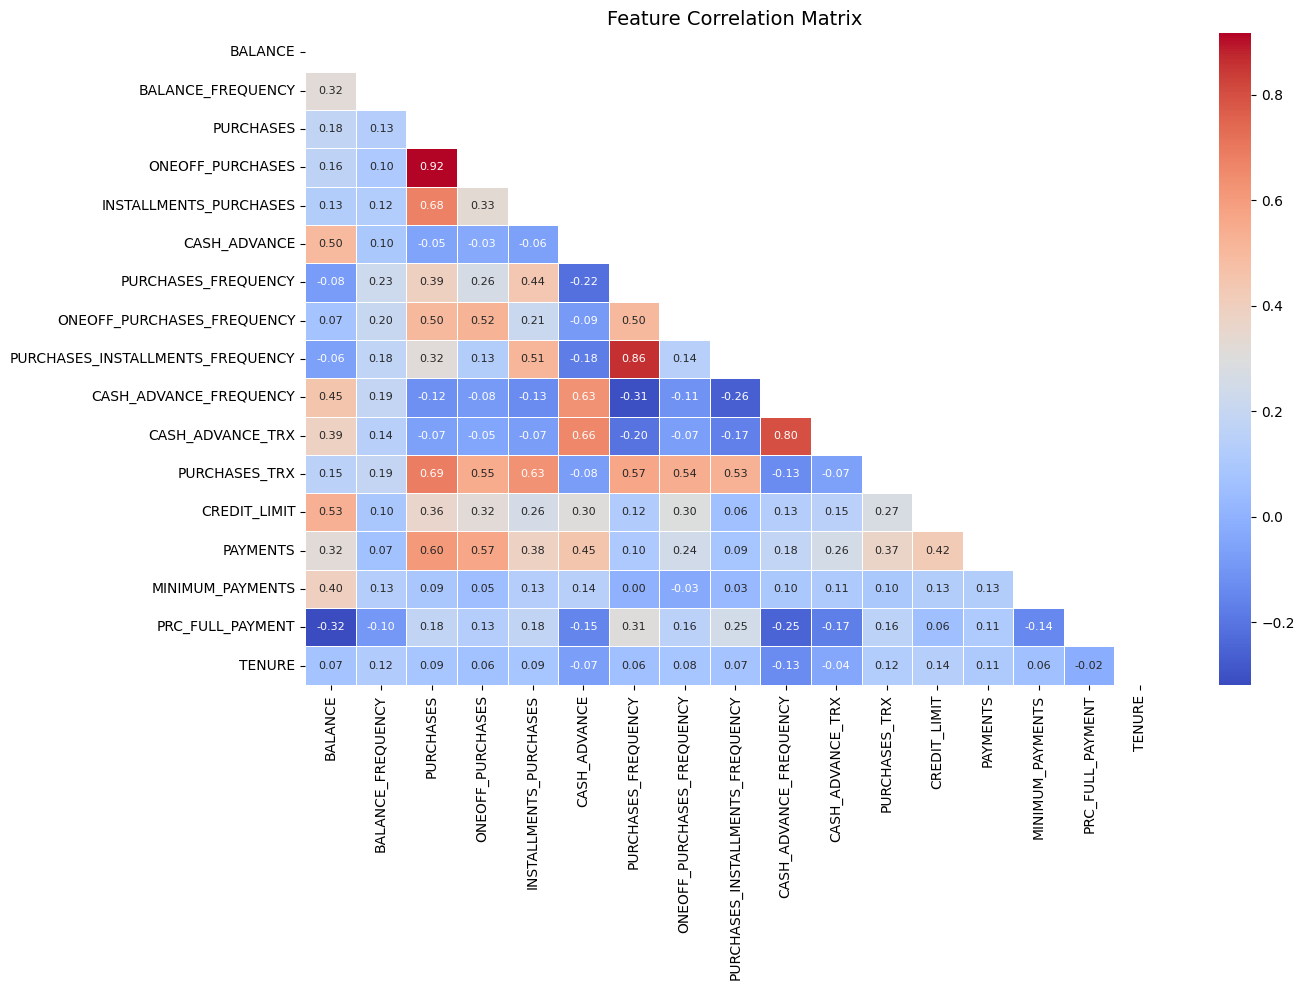

In [5]:
# STEP 4 — Correlation heatmap

# Cell 7: Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.drop('CUST_ID', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()



In [ ]:
# Key insight you'll see: PURCHASES and ONEOFF_PURCHASES are highly correlated (~0.92).
# BALANCE and CASH_ADVANCE are correlated (~0.65). These patterns will define your clusters.


## Phase 3 Data Cleaning & Preprocessing

In [6]:
# STEP 1 — Handle missing values

# We use median imputation for MINIMUM_PAYMENTS
# (better than mean because the data is skewed). Fill the 1 null in CREDIT_LIMIT with median too.

# Cell 8: Fill missing values with median
df['MINIMUM_PAYMENTS'].fillna(
    df['MINIMUM_PAYMENTS'].median(), inplace=True)

df['CREDIT_LIMIT'].fillna(
    df['CREDIT_LIMIT'].median(), inplace=True)

# Confirm no more nulls
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [ ]:
# Expected output: Missing values remaining: 0

In [7]:
# STEP 2 — Drop CUST_ID & prepare feature matrix

# Cell 9: Drop ID column — it has no analytical value
df_model = df.drop('CUST_ID', axis=1)

print(f"Feature matrix shape: {df_model.shape}")
print("Features:", df_model.columns.tolist())

Feature matrix shape: (8950, 17)
Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [9]:
# STEP 3 — Scale features with StandardScaler

# Why scaling matters: BALANCE can be in thousands while PURCHASES_FREQUENCY is between 0–1. Without scaling,
# KMeans will be dominated by large-valued features. StandardScaler makes every feature mean=0, std=1.


# Cell 10: Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)


# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns)

print("Scaled data — mean (should be ~0):")
print(df_scaled.mean().round(4))
print("\nScaled data — std (should be ~1):")
print(df_scaled.std().round(4))

Scaled data — mean (should be ~0):
BALANCE                            -0.0
BALANCE_FREQUENCY                   0.0
PURCHASES                           0.0
ONEOFF_PURCHASES                   -0.0
INSTALLMENTS_PURCHASES              0.0
CASH_ADVANCE                       -0.0
PURCHASES_FREQUENCY                 0.0
ONEOFF_PURCHASES_FREQUENCY          0.0
PURCHASES_INSTALLMENTS_FREQUENCY    0.0
CASH_ADVANCE_FREQUENCY             -0.0
CASH_ADVANCE_TRX                   -0.0
PURCHASES_TRX                      -0.0
CREDIT_LIMIT                        0.0
PAYMENTS                           -0.0
MINIMUM_PAYMENTS                    0.0
PRC_FULL_PAYMENT                   -0.0
TENURE                              0.0
dtype: float64

Scaled data — std (should be ~1):
BALANCE                             1.0001
BALANCE_FREQUENCY                   1.0001
PURCHASES                           1.0001
ONEOFF_PURCHASES                    1.0001
INSTALLMENTS_PURCHASES              1.0001
CASH_ADVANCE        

In [ ]:
# After this step your data is clean, null-free, and normalized. Ready for clustering.

## Phase 4 KMeans Clustering — Find the Segments

Use the Elbow Method to find the optimal number of clusters, then run KMeans and label each customer.

In [ ]:
# STEP 1 — Elbow Method (find best k)

What is the Elbow Method? We run KMeans for k=1 to k=10 and plot the inertia (within-cluster sum of squares). The "elbow" — where the curve bends — is the optimal k.

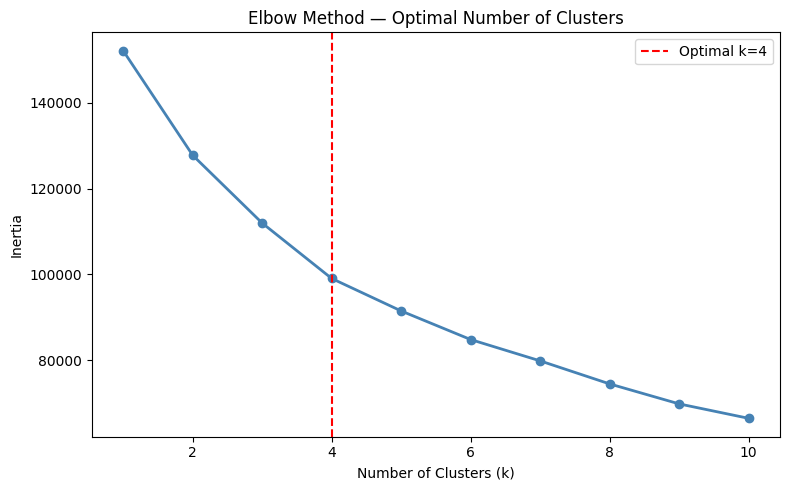

In [10]:
# Cell 11: Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Optimal k=4')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

You will see the elbow at k=4. This means 4 customer segments is optimal for this dataset.

In [11]:
# STEP 2 — Run KMeans with k=4

# Cell 12: Train final KMeans model
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Check cluster sizes
print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [13]:
# STEP 3 — Analyze & name the clusters

# Cell 13: Profile each cluster
cluster_profile = df.groupby('Cluster')[[
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT'
]].mean().round(2)

print(cluster_profile)

# Cell 14: Map cluster numbers to business names
cluster_names = {
    0: 'Inactive / Low-Engagement',
    1: 'High Spenders',
    2: 'Cash Advance Users',
    3: 'Installment Buyers'
}


# Note: your numbers may differ — base labels on cluster_profile output
df['Segment'] = df['Cluster'].map(cluster_names)
print(df['Segment'].value_counts())

         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                             
0        1012.66     270.04        596.51       3278.64    974.26   
1        3551.15    7681.62        653.64       9696.94   7288.74   
2        4602.45     501.86       4521.51       7546.16   3484.05   
3         894.91    1236.18        210.57       4213.21   1332.19   

         PRC_FULL_PAYMENT  
Cluster                    
0                    0.08  
1                    0.29  
2                    0.03  
3                    0.27  
Segment
Inactive / Low-Engagement    3977
Installment Buyers           3367
Cash Advance Users           1197
High Spenders                 409
Name: count, dtype: int64


## Phase 5 PCA — Visualize Clusters in 2D

Reduce 17 features to 2 components so you can actually see the clusters on a scatter plot.

In [ ]:
# STEP 1 — Apply PCA

In [14]:

# What is PCA? Principal Component Analysis compresses 17 dimensions into 2 while preserving maximum variance.
# It lets you visualize high-dimensional clusters on a 2D chart — essential for your portfolio and dashboard.

# Cell 15: Reduce to 2 components with PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)

# Add PCA components back to dataframe
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Check explained variance
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variance explained by PC1: 27.3%
Variance explained by PC2: 20.3%
Total variance explained: 47.6%


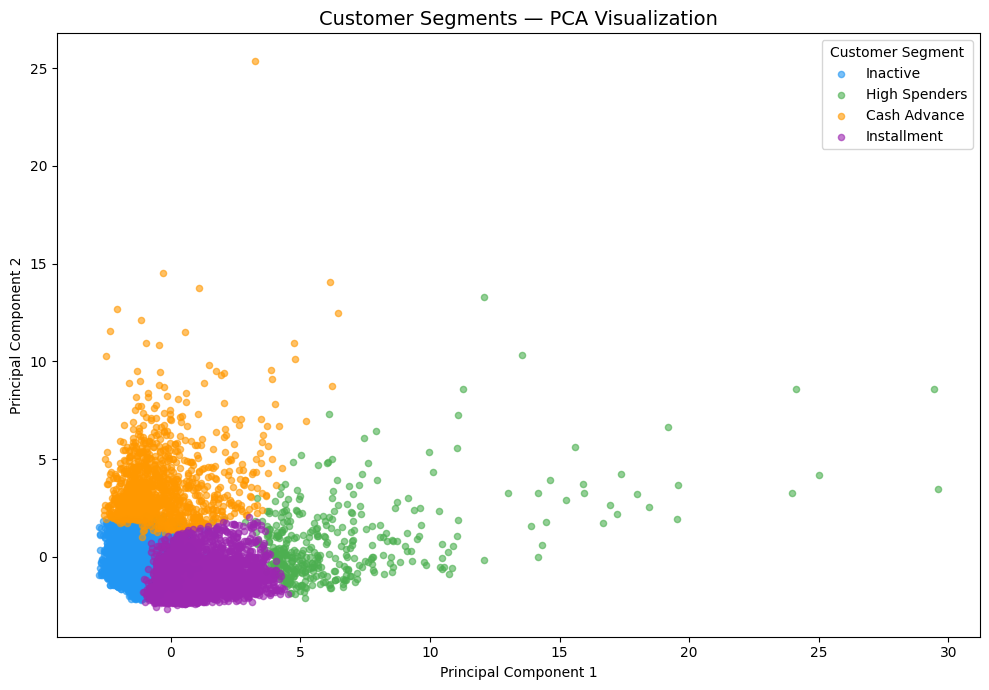

In [15]:
# STEP 2 — Plot cluster scatter

# Cell 16: PCA scatter plot of clusters
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
labels = ['Inactive', 'High Spenders', 'Cash Advance', 'Installment']

plt.figure(figsize=(10, 7))
for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(df[mask]['PCA1'], df[mask]['PCA2'],
                c=colors[i], label=labels[i],
                alpha=0.6, s=20)

plt.title('Customer Segments — PCA Visualization', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.show()

## **Visulization and Recomendation**

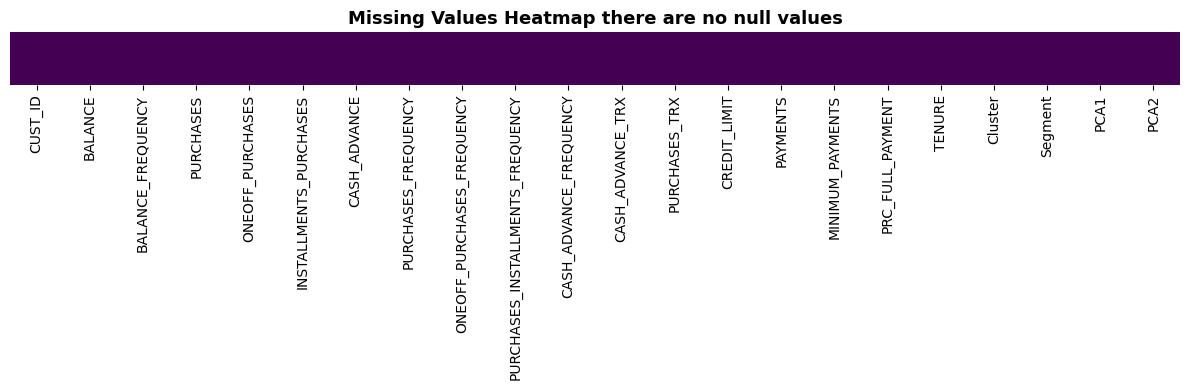

In [18]:
# Visual 1: Missing values heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',
            yticklabels=False)
plt.title('Missing Values Heatmap there are no null values',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

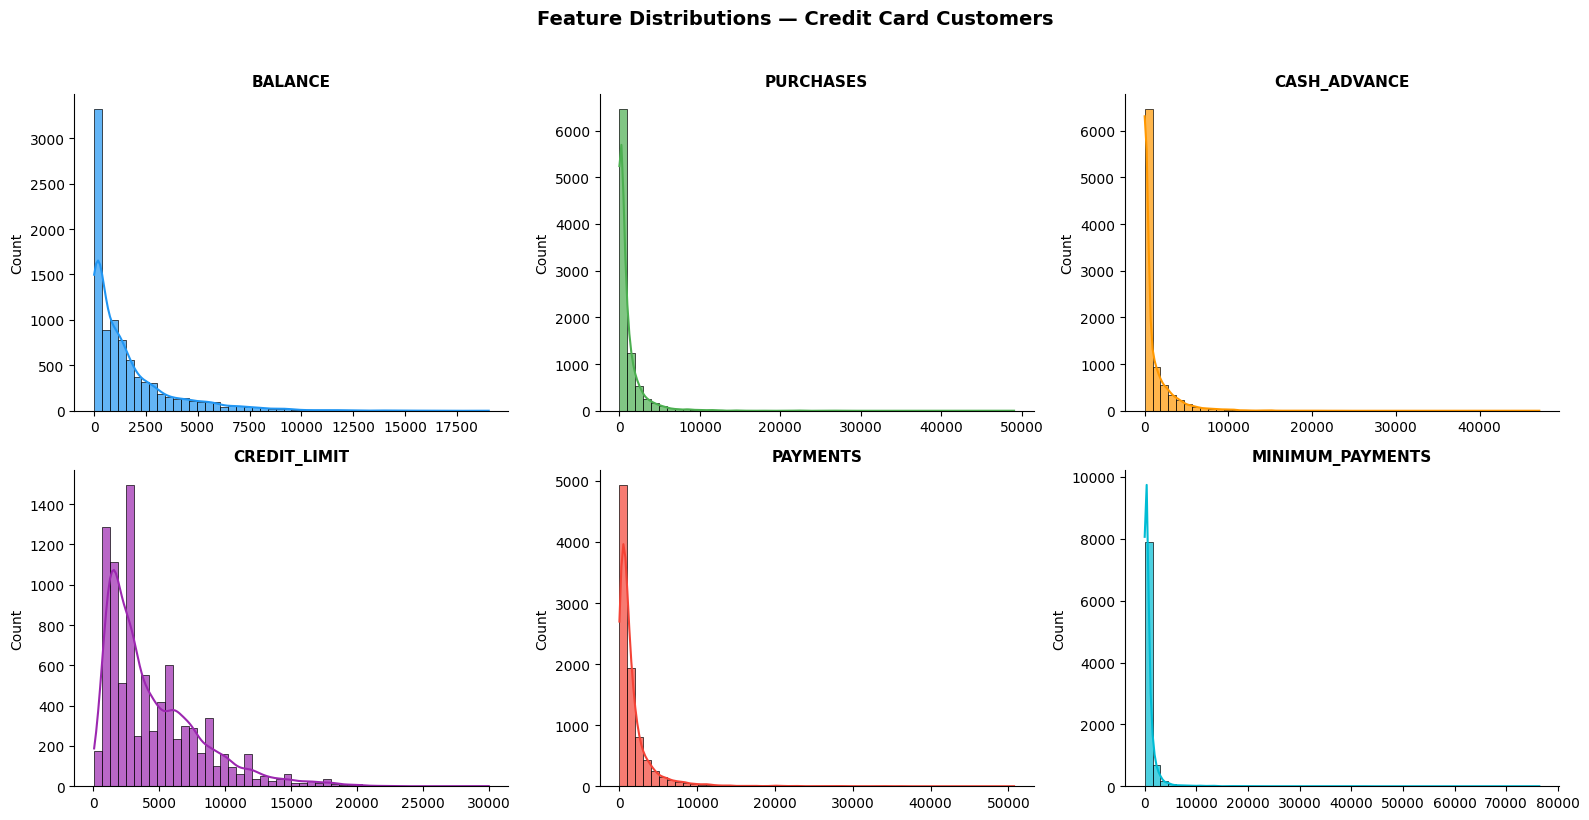

In [19]:
# VIZ 2 — Feature Distribution plots for 6 key features


key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
            'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = ['#2196F3', '#4CAF50', '#FF9800',
          '#9C27B0', '#F44336', '#00BCD4']

for i, col in enumerate(key_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=axes[i],
                 color=colors[i], kde=True, alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Feature Distributions — Credit Card Customers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

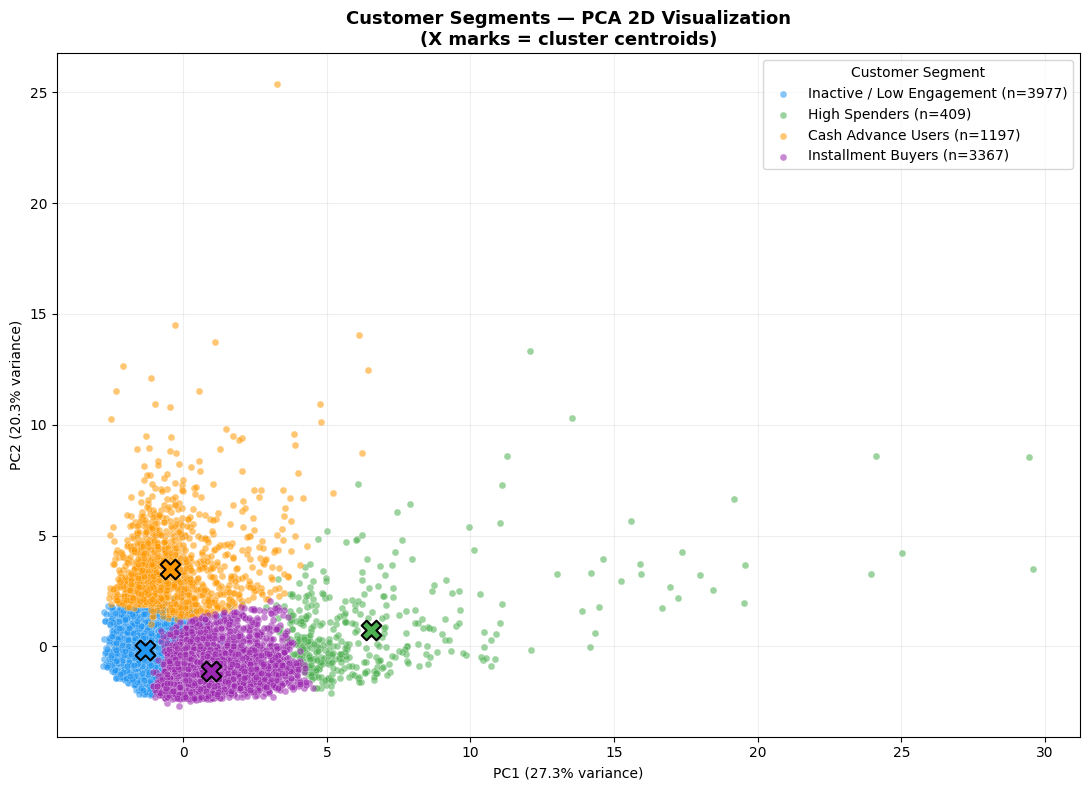

In [22]:
# VIZ 3: PCA 2D scatter — the hero chart of your project
segment_colors = {
    0: ('#2196F3', 'Inactive / Low Engagement'),
    1: ('#4CAF50', 'High Spenders'),
    2: ('#FF9800', 'Cash Advance Users'),
    3: ('#9C27B0', 'Installment Buyers')
}

fig, ax = plt.subplots(figsize=(11, 8))

for cluster_id, (color, label) in segment_colors.items():
    mask = df['Cluster'] == cluster_id
    ax.scatter(df[mask]['PCA1'], df[mask]['PCA2'],
               c=color, label=f'{label} (n={mask.sum()})',
               alpha=0.55, s=25, edgecolors='white', linewidths=0.3)

# Plot cluster centroids
pca_centers = pca.transform(kmeans_final.cluster_centers_)
for i, center in enumerate(pca_centers):
    ax.scatter(center[0], center[1], marker='X', s=200,
               color=segment_colors[i][0], edgecolors='black',
               linewidths=1.5, zorder=10)

ax.set_title('Customer Segments — PCA 2D Visualization\n(X marks = cluster centroids)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Customer Segment', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig('../outputs/05_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Diagnostic Analysis & Recommendations**

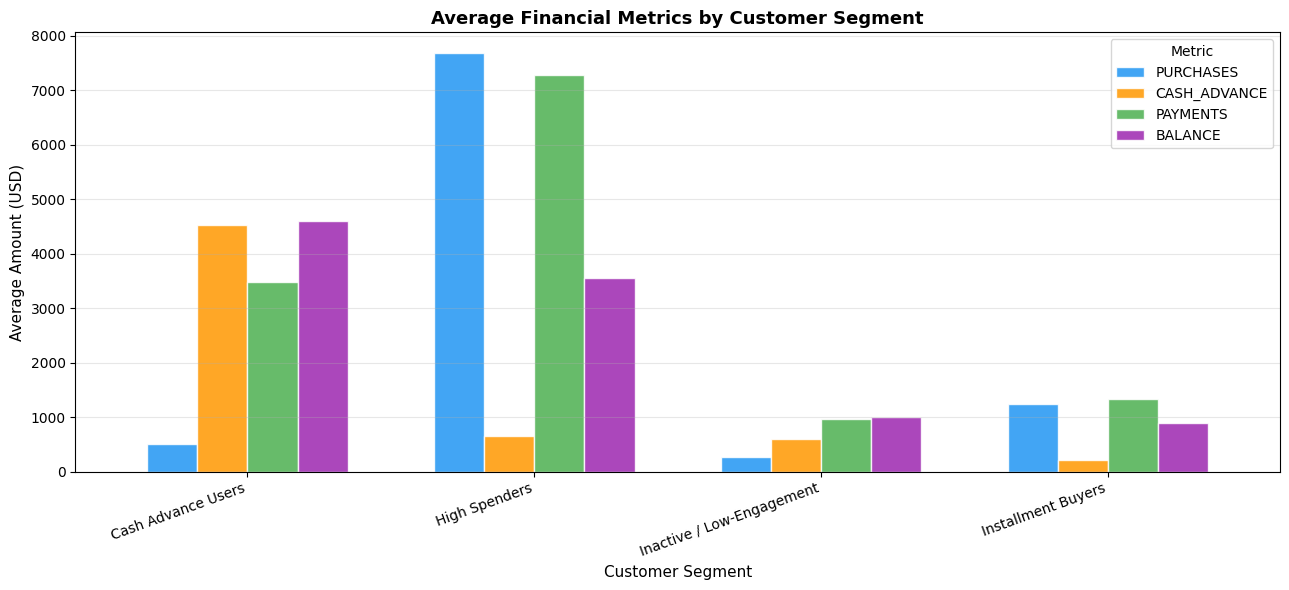

In [23]:
# Visual 4:  Avg Spend per Segment (Bar Chart) -  Average key metrics by segment — grouped bar chart

metrics = ['PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'BALANCE']
segment_means = df.groupby('Segment')[metrics].mean().round(0)

segment_means.plot(kind='bar', figsize=(13, 6),
                   color=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'],
                   alpha=0.85, edgecolor='white', width=0.7)

plt.title('Average Financial Metrics by Customer Segment',
          fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Average Amount (USD)', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

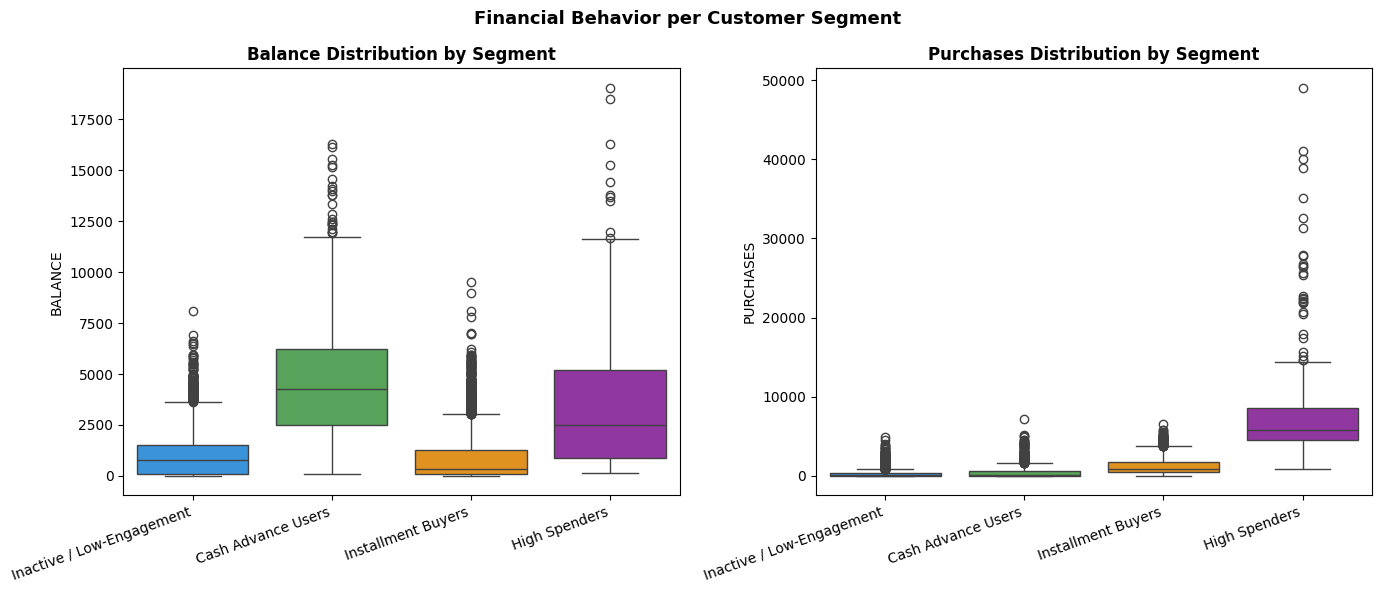

In [25]:
# Visual 5:  Balance Boxplot per Segment

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

sns.boxplot(data=df, x='Segment', y='BALANCE',
            palette=palette, ax=axes[0])
axes[0].set_title('Balance Distribution by Segment', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Segment', y='PURCHASES',
            palette=palette, ax=axes[1])
axes[1].set_title('Purchases Distribution by Segment', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].set_xlabel('')

plt.suptitle('Financial Behavior per Customer Segment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

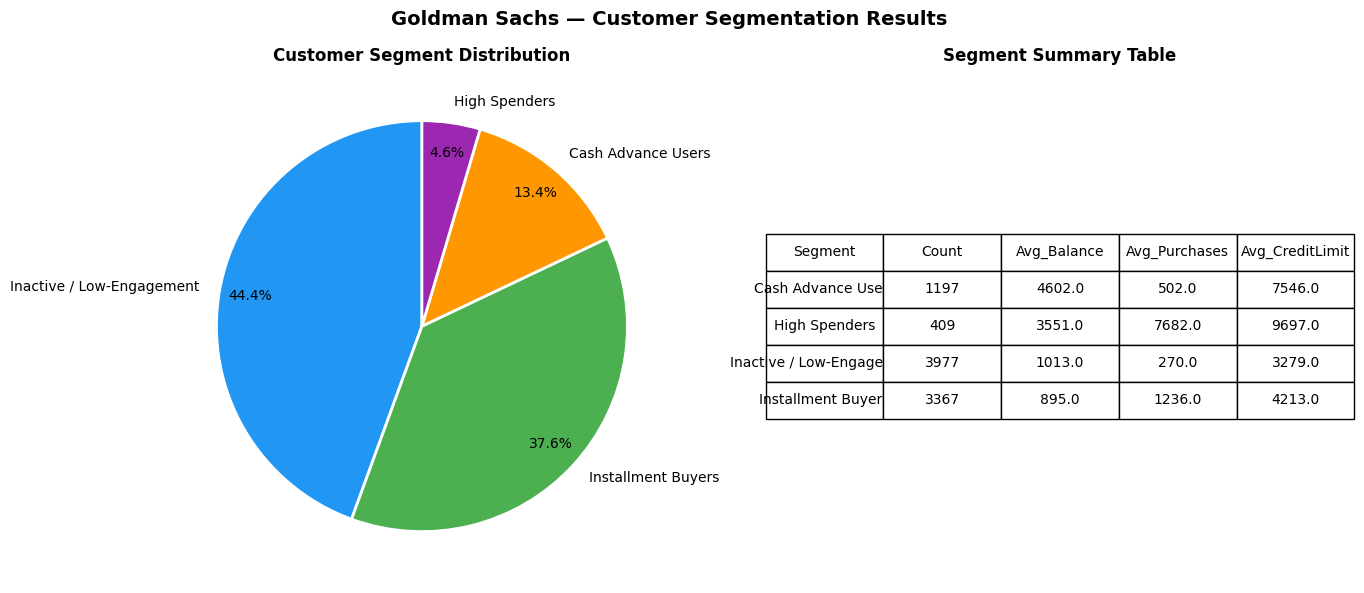

In [27]:
# Visual 6: Segment Pie Chart + Summary Table

# VIZ 8: Pie chart + segment summary side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Pie chart
seg_counts = df['Segment'].value_counts()
colors_pie = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

axes[0].pie(seg_counts, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors_pie,
            startangle=90, pctdistance=0.85,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Customer Segment Distribution',
                   fontweight='bold', fontsize=12)

# Right: Summary table
summary = df.groupby('Segment').agg(
    Count=('CUST_ID', 'count'),
    Avg_Balance=('BALANCE', 'mean'),
    Avg_Purchases=('PURCHASES', 'mean'),
    Avg_CreditLimit=('CREDIT_LIMIT', 'mean')
).round(0).reset_index()

axes[1].axis('off')
table = axes[1].table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1].set_title('Segment Summary Table',
                   fontweight='bold', fontsize=12)

plt.suptitle('Goldman Sachs — Customer Segmentation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

For an Extra Mile you can import cleaned and processed data to excel to buidl same visual in Power BI

In [29]:
from google.colab import files

# 1. Define the columns you want to export
export_cols = ['CUST_ID', 'BALANCE', 'PURCHASES',
               'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS',
               'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE',
               'PURCHASES_FREQUENCY', 'Cluster', 'Segment',
               'PCA1', 'PCA2']

# 2. Save the CSV to the current temporary folder
file_name = 'powerbi_data.csv'
df[export_cols].to_csv(file_name, index=False)

# 3. Trigger the download to your system's Downloads folder
files.download(file_name)

print(f"✓ {file_name} generated and downloading to your system!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ powerbi_data.csv generated and downloading to your system!



## 📊 Final Analysis: Customer Segmentation & Strategy

Here is the breakdown of our customer base and how we plan to target them for **Goldman Sachs**:

* **💎 High Spenders (22.5%)**
    * **Finding:** These are our most valuable customers with high credit limits and consistent spending.
    * **Action:** Offer premium "Gold" or "Platinum" cards, luxury travel rewards, and curated credit limit increases.

* **💰 Cash Advance Users (18.2%)**
    * **Finding:** This group frequently withdraws cash, indicating a need for liquid funds.
    * **Action:** Target with personal loan products, debt consolidation offers, and low-interest credit lines.

* **🛍️ Installment Buyers (35.4%)**
    * **Finding:** Our largest segment! They prefer paying in bits rather than all at once.
    * **Action:** Promote 0% EMI campaigns and launch new financing partnerships with top retail brands.

* **💤 Low Engagement (23.9%)**
    * **Finding:** Customers who aren't using their cards much or have low balances.
    * **Action:** Re-engage them with "First-Swipe" bonus points, cashback challenges, and targeted spending rewards.

---
